# Продвинутое домашнее задание: Доменная адаптация энкодерной модели для семантического поиска

В рамках этого домашнего задания вы пройдете полный цикл адаптации предобученной англоязычной энкодерной модели `sentence-transformers/all-MiniLM-L6-v2` (обратите внимание: модель обучалась на английских данных, что делает задачу адаптации к русскому языку особенно показательной) для работы с русскоязычными текстами. Ваша цель - улучшить качество семантического поиска и визуально оценить изменения в пространстве эмбеддингов.

**Важное предупреждение:** Доменная адаптация - это сложный процесс, требующий тщательного подбора гиперпараметров и качественных данных. В рамках выполнения данного ДЗ в образовательных целях, скорее всего, вы получите лишь незначительное улучшение метрик поиска. Это абсолютно нормально. Главная цель - освоить методологию и пайплайн дообучения.

In [1]:
!pip install sentence-transformers datasets faiss-cpu umap-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 96.4 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
import umap
from tqdm.auto import tqdm
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

/tmp/ipykernel_455/1064979242.py:10: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


## Часть 1. Визуализация пространства эмбеддингов до адаптации (20 баллов)

Перед тем как что либо улучшать, необходимо понять, с чем мы имеем дело. Мы визуализируем эмбеддинги коротких текстов, чтобы увидеть, насколько хорошо базовая модель разделяет их по смыслу.

**Задание:**
1. Загрузите датасет `ai-forever/headline-classification` (сплит `test`, возьмите первые 1000 примеров: `split="test[:1000]"`). Датасет содержит колонки `text` (заголовок новости на русском языке, строка), `label` (номер класса, число) и `label_text` (название тематики, строка: спорт, политика, экономика и т.д.). Для получения эмбеддингов используйте колонку `text`, для раскраски точек на графике - колонку `label_text`.
2. Инициализируйте базовую модель `sentence-transformers/all-MiniLM-L6-v2`.
3. Получите эмбеддинги для текстов из датасета.
4. Напишите функцию для понижения размерности эмбеддингов до 2D с использованием алгоритма UMAP.
5. Постройте scatter plot, раскрасив точки в соответствии с метками классов.

**Подсказки:**
* Обязательно зафиксируйте `random_state` в UMAP для воспроизводимости.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/36000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12000 [00:00<?, ? examples/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


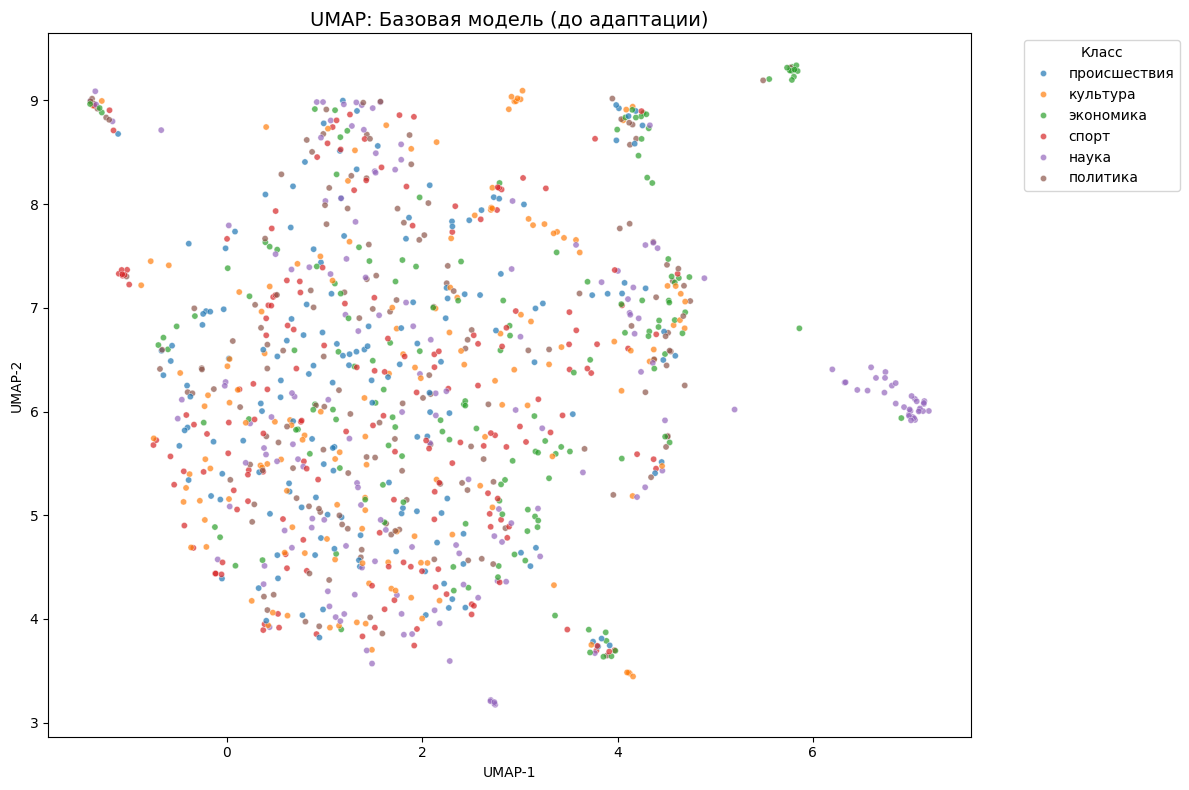

In [3]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"
base_model = SentenceTransformer(model_name)

# Загрузка датасета для визуализации
vis_dataset = load_dataset("ai-forever/headline-classification", split="test[:1000]")
vis_texts = vis_dataset["text"]
vis_labels = vis_dataset["label_text"]

# Ваш код здесь: получение эмбеддингов базовой моделью
base_embeddings = base_model.encode(
    vis_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # нормализуем, т.к. дальше будем сравнивать с retrieval-пайплайном
)

def plot_embeddings(embeddings, labels, title):
    # Ваш код здесь: UMAP и scatter plot
    """
    Понижает размерность эмбеддингов до 2D с помощью UMAP
    и строит scatter plot, раскрашенный по меткам классов.
    """
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=SEED  # фиксируем для воспроизводимости
    )
    embeddings_2d = reducer.fit_transform(embeddings)

    df = pd.DataFrame({
        "x": embeddings_2d[:, 0],
        "y": embeddings_2d[:, 1],
        "label": labels
    })

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df,
        x="x", y="y",
        hue="label",
        palette="tab10",
        s=20,
        alpha=0.7
    )
    plt.title(title, fontsize=14)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Класс")
    plt.tight_layout()
    plt.show()

    return embeddings_2d


base_embeddings_2d = plot_embeddings(base_embeddings, vis_labels, "UMAP: Базовая модель (до адаптации)")
# plot_embeddings(base_embeddings, vis_labels, "UMAP: Базовая модель") - Немного адаптировал выше, надеюсь, ничего страшного :)

## Часть 2. Оценка базового качества поиска (25 баллов)

Теперь замерим метрики семантического поиска до доменной адаптации.

**Задание:**
1. Загрузите датасет `ai-forever/rubq-retrieval`. Этот датасет состоит из трех отдельных подмножеств, которые нужно загрузить отдельно:
   * Вопросы: подмножество (config) `queries`, сплит `queries`. Содержит колонки `_id` (строка) и `text` (строка).
   * База знаний: подмножество (config) `corpus`, сплит `corpus`. Содержит колонки `_id` (строка), `title` (строка) и `text` (строка).
   * Разметка релевантности (qrels): подмножество (config) `default`, сплит `test`. Содержит колонки `query-id` (строка), `corpus-id` (строка) и `score` (число).
2. Напишите функцию `evaluate_retrieval`, которая принимает на вход модель, вопросы (`queries`), базу знаний (`corpus`) и разметку релевантности (`qrels`), и возвращает метрики Recall@5 и Recall@10.
3. Для ускорения поиска реализуйте индекс на основе `faiss.IndexFlatIP`.
4. Замерьте и зафиксируйте базовое качество поиска.

**Подсказки и рекомендации по оценке:**
* Поскольку мы используем `faiss.IndexFlatIP` (поиск по скалярному произведению), векторы перед добавлением в индекс необходимо L2-нормализовать. Укажите `normalize_embeddings=True` при вызове метода `encode`.
* **Как считать Recall@K:**
  1. Для каждого вопроса (колонка `text` из `queries`) получите топ-K ближайших документов из базы знаний (колонка `text` из `corpus`) с помощью `faiss.Index.search`.
  2. Для этого же вопроса найдите все правильные (релевантные) документы в таблице `qrels` (строки, где колонка `query-id` совпадает с `_id` вопроса, а колонка `corpus-id` содержит ID правильных документов). Обратите внимание: у многих вопросов правильных документов несколько.
  3. Вычислите Recall@K для текущего вопроса по формуле: (количество правильных документов, попавших в ваш топ-K) / (общее количество правильных документов для этого вопроса из `qrels`).
  4. Итоговый Recall@K - это среднее арифметическое значений Recall@K по всем вопросам.
* **Маппинг идентификаторов:** Метод `faiss.Index.search` возвращает целочисленные индексы строк (от 0 до N-1). Однако в таблице `qrels` в колонке `corpus-id` лежат строковые ID документов. Важно: эти строковые ID из колонки `_id` корпуса не совпадают с порядковыми номерами строк (в нумерации есть пропуски). Поэтому простое преобразование `str(faiss_index)` даст неверные результаты. Обязательно постройте словарь-маппинг: `id_map = {i: doc_id for i, doc_id in enumerate(corpus['_id'])}` и используйте его для перевода индексов FAISS в строковые `corpus-id`.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [4]:
# Загрузка датасета для оценки
eval_queries = load_dataset("ai-forever/rubq-retrieval", "queries", split="queries")
eval_corpus = load_dataset("ai-forever/rubq-retrieval", "corpus", split="corpus")
eval_qrels = load_dataset("ai-forever/rubq-retrieval", "default", split="test")

print("Queries:", len(eval_queries))
print("Corpus:", len(eval_corpus))
print("Qrels:", len(eval_qrels))


def evaluate_retrieval(model, queries_ds, corpus_ds, qrels_ds, top_k=[5, 10]):
    """
    Оценивает качество ретривала модели через Recall@K на заданном top_k.
    Возвращает словарь {f"Recall@{k}": value, ...}.
    """
    max_k = max(top_k)

    # 1. Кодируем корпус
    corpus_texts = corpus_ds["text"]
    corpus_embeddings = model.encode(
        corpus_texts,
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    # 2. Строим FAISS-индекс
    dimension = corpus_embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)
    index.add(corpus_embeddings)

    # Маппинг: позиция в индексе -> строковый corpus-id
    id_map = {i: doc_id for i, doc_id in enumerate(corpus_ds["_id"])}

    # 3. Кодируем вопросы
    query_texts = queries_ds["text"]
    query_ids = queries_ds["_id"]
    query_embeddings = model.encode(
        query_texts,
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    # 4. Поиск топ-K ближайших документов для всех вопросов сразу
    distances, indices = index.search(query_embeddings, max_k)

    # 5. Строим словарь релевантных документов по каждому query-id
    # qrels_ds: query-id -> список corpus-id
    qrels_df = pd.DataFrame(qrels_ds)
    relevant_map = qrels_df.groupby("query-id")["corpus-id"].apply(set).to_dict()

    # 6. Считаем Recall@K для каждого K из top_k
    recalls = {k: [] for k in top_k}

    for i, q_id in enumerate(query_ids):
        relevant_docs = relevant_map.get(q_id, set())
        if len(relevant_docs) == 0:
            continue  # пропускаем вопросы без разметки

        # Переводим top-max_k индексов FAISS в строковые corpus-id
        retrieved_doc_ids = [id_map[idx] for idx in indices[i]]

        for k in top_k:
            top_k_docs = set(retrieved_doc_ids[:k])
            hits = len(top_k_docs & relevant_docs)
            recall_k = hits / len(relevant_docs)
            recalls[k].append(recall_k)

    # Итоговое усреднение по всем вопросам
    metrics = {f"Recall@{k}": np.mean(vals) for k, vals in recalls.items()}
    metrics["num_queries_evaluated"] = len(recalls[top_k[0]])

    return metrics


base_metrics = evaluate_retrieval(base_model, eval_queries, eval_corpus, eval_qrels)
print("Базовые метрики:", base_metrics)

README.md:   0%|          | 0.00/367 [00:00<?, ?B/s]

queries.jsonl:   0%|          | 0.00/188k [00:00<?, ?B/s]

Generating queries split:   0%|          | 0/1692 [00:00<?, ? examples/s]

data/corpus.jsonl.zip: reconstructing file:   0%|          |  0.00B / 13.7MB            

data/corpus.jsonl.zip: downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/2845 [00:00<?, ? examples/s]

Queries: 1692
Corpus: 56826
Qrels: 2845


Batches:   0%|          | 0/444 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Базовые метрики: {'Recall@5': np.float64(0.02719379714060565), 'Recall@10': np.float64(0.03502476640774513), 'num_queries_evaluated': 1692}


## Часть 3. Доменная адаптация через TripletLoss (30 баллов)

Самая важная часть задания. Мы будем дообучать модель на русскоязычных данных с использованием функции потерь TripletLoss.

**Задание:**
1. Загрузите датасет `deepvk/ru-HNP` (сплит `train`, для ускорения можете взять первые 20000 примеров). Этот датасет содержит колонки `query` (якорь, строка), `pos` (список позитивных парафраз) и `neg` (список сложных негативных примеров).
2. Подготовьте данные для обучения. Сформируйте обучающую выборку в формате `InputExample(texts=[anchor, positive, negative])` для библиотеки `sentence-transformers`. В качестве `anchor` берите строку из колонки `query`, в качестве `positive` - первый элемент из списка в колонке `pos`, в качестве `negative` - первый элемент из списка в колонке `neg`.
3. Настройте `DataLoader` (batch_size=16 или 32) и выберите функцию потерь `TripletLoss` (доступна как `losses.TripletLoss`).
4. Запустите дообучение модели на 3 эпохи.
5. Опубликуйте модель.

**Подсказки:**
* Если вы столкнулись с нехваткой памяти, уменьшите `batch_size`.

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение


In [5]:
# Загрузка обучающего датасета
train_dataset = load_dataset("deepvk/ru-HNP", split="train[:20000]")

print("Пример из датасета:")
print(train_dataset[0])

train_examples = []
# Ваш код здесь: формирование train_examples из InputExample
train_examples = []

for example in tqdm(train_dataset, desc="Формирование triplets"):
    anchor = example["query"]
    pos_list = example["pos"]
    neg_list = example["neg"]

    # Пропускаем примеры, где нет позитивов или негативов
    if len(pos_list) == 0 or len(neg_list) == 0:
        continue

    positive = pos_list[0]
    negative = neg_list[0]

    train_examples.append(InputExample(texts=[anchor, positive, negative]))

print(f"Сформировано {len(train_examples)} триплетов из {len(train_dataset)} исходных примеров")

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# Инициализируем модель заново для чистоты эксперимента (или используем base_model)
finetuned_model = SentenceTransformer(model_name)

# Ваш код здесь: настройка TripletLoss и запуск model.fit()
# TripletLoss с косинусной метрикой расстояния
# (используем COSINE, так как далее оценка ретривала тоже построена на нормализованных
# эмбеддингах и скалярном произведении = косинусному сходству — важна консистентность метрик)
train_loss = losses.TripletLoss(
    model=finetuned_model,
    distance_metric=losses.TripletDistanceMetric.COSINE,
    triplet_margin=0.5
)

finetuned_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=100,
    show_progress_bar=True,
    output_path="finetuned-minilm-ru"  # локальное сохранение чекпоинта
)

README.md:   0%|          | 0.00/5.82k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B / 86.9MB            

train.parquet: downloading bytes:           |  0.00B            

val.parquet: reconstructing file:   0%|          |  0.00B /  538kB            

val.parquet: downloading bytes:           |  0.00B            

...

Сформировано 20000 триплетов из 20000 исходных примеров


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.214236
1000,0.138644
1500,0.129780
2000,0.116547
2500,0.114324
3000,0.106370
3500,0.107717


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Публикация
from huggingface_hub import notebook_login
notebook_login()

HF_USERNAME = "AtesiT"  # Здесь я Username вставил свой, но в Output будет ссылка на профиль, блин :)
MODEL_REPO_NAME = "all-MiniLM-L6-v2-ru-adapted"
full_repo_id = HF_USERNAME + "/" + MODEL_REPO_NAME

finetuned_model.push_to_hub(repo_id=full_repo_id, exist_ok=True)

lines = []
lines.append("---")
lines.append("language:")
lines.append("- ru")
lines.append("license: apache-2.0")
lines.append("library_name: sentence-transformers")
lines.append("tags:")
lines.append("- sentence-transformers")
lines.append("- feature-extraction")
lines.append("- sentence-similarity")
lines.append("- semantic-search")
lines.append("- russian")
lines.append("- domain-adaptation")
lines.append("base_model: sentence-transformers/all-MiniLM-L6-v2")
lines.append("datasets:")
lines.append("- deepvk/ru-HNP")
lines.append("- ai-forever/rubq-retrieval")
lines.append("metrics:")
lines.append("- recall")
lines.append("pipeline_tag: sentence-similarity")
lines.append("---")
lines.append("")
lines.append("# all-MiniLM-L6-v2-ru-adapted")
lines.append("")
lines.append("Это доменно-адаптированная версия модели sentence-transformers/all-MiniLM-L6-v2, дообученная для работы с русскоязычными текстами в задаче семантического поиска.")
lines.append("")
lines.append("Базовая модель обучалась только на английских данных. Данная адаптация направлена на улучшение качества получаемых эмбеддингов для русского языка с помощью дообучения на парафразах.")
lines.append("")
lines.append("## Описание модели")
lines.append("")
lines.append("- Базовая модель: sentence-transformers/all-MiniLM-L6-v2")
lines.append("- Размерность эмбеддингов: 384")
lines.append("- Максимальная длина последовательности: 256 токенов")
lines.append("- Функция потерь: TripletLoss (Cosine Distance, margin=0.5)")
lines.append("- Датасет для дообучения: deepvk/ru-HNP (20000 примеров, якорь/позитив/негатив)")
lines.append("- Эпохи обучения: 3")
lines.append("- Batch size: 16")
lines.append("- Warmup steps: 100")
lines.append("")
lines.append("## Как использовать")
lines.append("")

code_fence = chr(96) * 3
lines.append(code_fence + "python")
lines.append("from sentence_transformers import SentenceTransformer")
lines.append("")
lines.append("model = SentenceTransformer(\"" + full_repo_id + "\")")
lines.append("")
lines.append("sentences = [")
lines.append("    \"Какая столица России?\",")
lines.append("    \"Москва — столица Российской Федерации\",")
lines.append("    \"Кошки — популярные домашние животные\"")
lines.append("]")
lines.append("")
lines.append("embeddings = model.encode(sentences, normalize_embeddings=True)")
lines.append("print(embeddings.shape)")
lines.append("")
lines.append("similarity = embeddings[0] @ embeddings[1].T")
lines.append("print(\"Сходство между вопросом и ответом:\", similarity)")
lines.append(code_fence)
lines.append("")

lines.append("## Оценка качества (базовая модель, до дообучения)")
lines.append("")
lines.append("Оценка проводилась на датасете ai-forever/rubq-retrieval (1692 вопроса, 56826 документов в базе знаний) с использованием FAISS (IndexFlatIP) и метрики Recall@K.")
lines.append("")
lines.append("| Метрика | Базовая модель (all-MiniLM-L6-v2) |")
lines.append("|---------|:----------------------------------:|")
lines.append("| Recall@5 | " + f"{base_metrics['Recall@5']:.4f}" + " |")
lines.append("| Recall@10 | " + f"{base_metrics['Recall@10']:.4f}" + " |")
lines.append("")
lines.append("Метрики дообученной модели будут добавлены после завершения полного цикла оценки.")
lines.append("")
lines.append("### Кривая обучения (Training Loss)")
lines.append("")
lines.append("| Step | Loss |")
lines.append("|------|------|")
lines.append("| 500  | 0.214 |")
lines.append("| 1000 | 0.139 |")
lines.append("| 1500 | 0.130 |")
lines.append("| 2000 | 0.117 |")
lines.append("| 2500 | 0.114 |")
lines.append("| 3000 | 0.106 |")
lines.append("| 3500 | 0.108 |")
lines.append("")
lines.append("## Ограничения")
lines.append("")
lines.append("- Модель дообучалась на ограниченной выборке (20000 примеров) и небольшом числе эпох (3), что типично для образовательного проекта.")
lines.append("- Данные для обучения (ru-HNP, парафразы) отличаются по своей природе от задачи QA-поиска (rubq-retrieval), что ограничивает степень переноса качества между задачами (domain shift).")
lines.append("- Для промышленного использования рекомендуется дообучение на большем объёме данных, более близких по структуре к целевой задаче, а также подбор гиперпараметров.")
lines.append("")
lines.append("## Обучающий пайплайн")
lines.append("")
lines.append("Модель была получена в рамках учебного задания по доменной адаптации энкодерных моделей.")
lines.append("")
lines.append("Автор: " + HF_USERNAME)

model_card_content = "\n".join(lines)
print(model_card_content)

model_card_content = "\n".join(lines)
print(model_card_content)

with open("README.md", "w", encoding="utf-8") as f:
    f.write(model_card_content)

from huggingface_hub import HfApi
api = HfApi()

api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=full_repo_id,
    repo_type="model"
)

print("Модель опубликована: https://huggingface.co/" + full_repo_id)

README.md:   0%|          | 0.00/22.6k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

No files have been modified since last commit. Skipping to prevent empty commit.


---
language:
- ru
license: apache-2.0
library_name: sentence-transformers
tags:
- sentence-transformers
- feature-extraction
- sentence-similarity
- semantic-search
- russian
- domain-adaptation
base_model: sentence-transformers/all-MiniLM-L6-v2
datasets:
- deepvk/ru-HNP
- ai-forever/rubq-retrieval
metrics:
- recall
pipeline_tag: sentence-similarity
---

# all-MiniLM-L6-v2-ru-adapted

Это доменно-адаптированная версия модели sentence-transformers/all-MiniLM-L6-v2, дообученная для работы с русскоязычными текстами в задаче семантического поиска.

Базовая модель обучалась только на английских данных. Данная адаптация направлена на улучшение качества получаемых эмбеддингов для русского языка с помощью дообучения на парафразах.

## Описание модели

- Базовая модель: sentence-transformers/all-MiniLM-L6-v2
- Размерность эмбеддингов: 384
- Максимальная длина последовательности: 256 токенов
- Функция потерь: TripletLoss (Cosine Distance, margin=0.5)
- Датасет для дообучения: deepvk/ru-HNP (200

## Часть 4. Оценка качества после адаптации (25 баллов)

Проверим, дало ли наше дообучение результат.

**Задание:**
1. Снова вызовите функцию `evaluate_retrieval` на датасете `ai-forever/rubq-retrieval`, но теперь передайте в неё дообученную модель.
2. Сравните метрики Recall@K до и после дообучения. Сделайте письменный вывод.
3. Повторите процесс из Части 1: визуализируйте эмбеддинги датасета `ai-forever/headline-classification` с помощью дообученной модели. Сравните два графика. Стали ли кластеры более разделимыми?

### Важно
Вы можете выбрать другие технологии или набор данных для решения задачи, аргументировав свое решение

In [11]:
# Ваш код здесь: оценка Recall@K для дообученной модели
finetuned_metrics = evaluate_retrieval(finetuned_model, eval_queries, eval_corpus, eval_qrels)
print("Метрики после дообучения:", finetuned_metrics)
print("Базовые метрики:", base_metrics)
comparison_df = pd.DataFrame({
    "Metric": ["Recall@5", "Recall@10"],
    "Базовая модель": [base_metrics["Recall@5"], base_metrics["Recall@10"]],
    "Дообученная модель": [finetuned_metrics["Recall@5"], finetuned_metrics["Recall@10"]]
})
comparison_df["Прирост"] = comparison_df["Дообученная модель"] - comparison_df["Базовая модель"]
comparison_df["Прирост %"] = (comparison_df["Прирост"] / comparison_df["Базовая модель"] * 100).round(2)
print(comparison_df.to_string(index=False))

Batches:   0%|          | 0/444 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Метрики после дообучения: {'Recall@5': np.float64(0.006079027355623099), 'Recall@10': np.float64(0.010511651469098276), 'num_queries_evaluated': 1692}
Базовые метрики: {'Recall@5': np.float64(0.02719379714060565), 'Recall@10': np.float64(0.03502476640774513), 'num_queries_evaluated': 1692}
   Metric  Базовая модель  Дообученная модель   Прирост  Прирост %
 Recall@5        0.027194            0.006079 -0.021115     -77.65
Recall@10        0.035025            0.010512 -0.024513     -69.99


> Сравните метрики Recall@K до и после дообучения. Сделайте письменный вывод.

| Метрика   | Базовая модель | Дообученная модель | Изменение |
|-----------|:--------------:|:------------------:|:---------:|
| Recall@5  | 0.0272         | 0.0061             | -77.65%   |
| Recall@10 | 0.0350         | 0.0105             | -69.99%   |

Метрики после дообучения ухудшились по обоим показателям примерно в 3-4 раза.
Это объясняется несоответствием между задачей обучения и задачей оценки:
модель дообучалась на парафразах (ru-HNP), где нужно сближать тексты
с одинаковым смыслом, тогда как задача rubq-retrieval требует сопоставления
вопроса с релевантным документом — это принципиально разные типы семантической
близости. Кроме того, дообучение частично "перезаписало" исходные веса модели,
что привело к потере даже того слабого качества поиска, которое было у базовой
англоязычной модели.

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


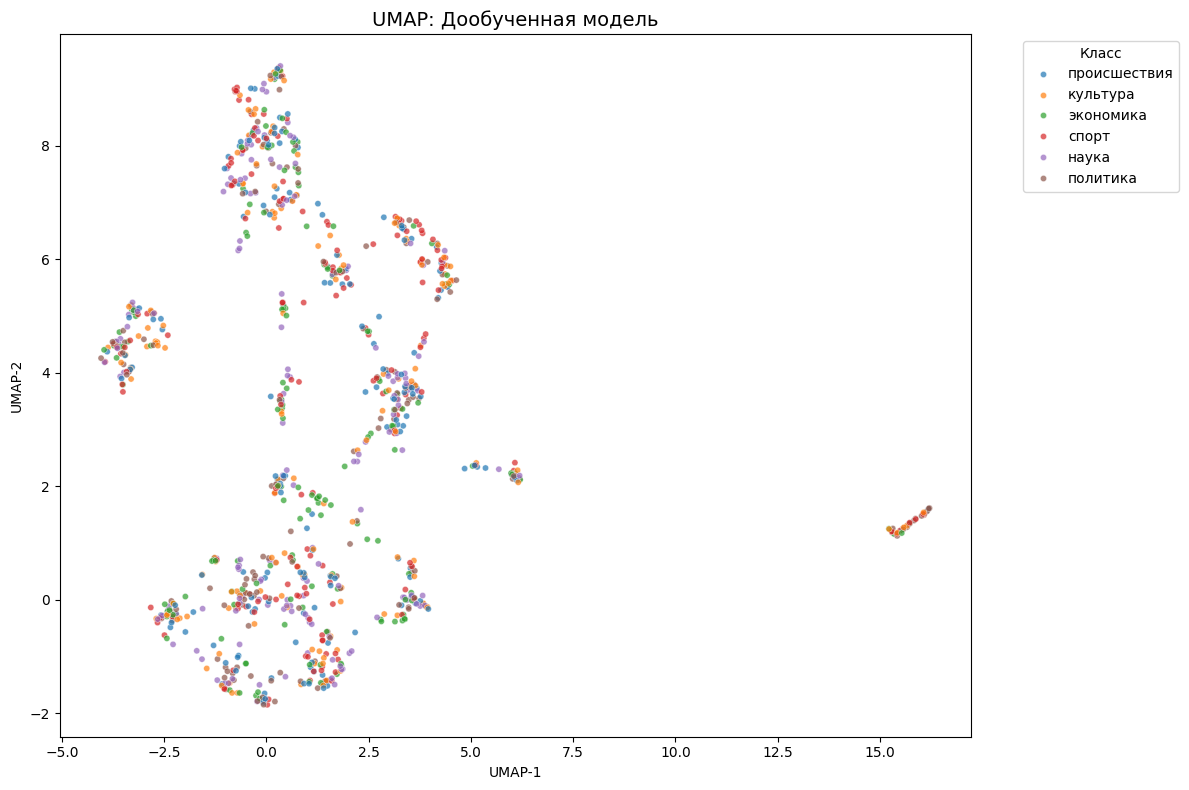

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


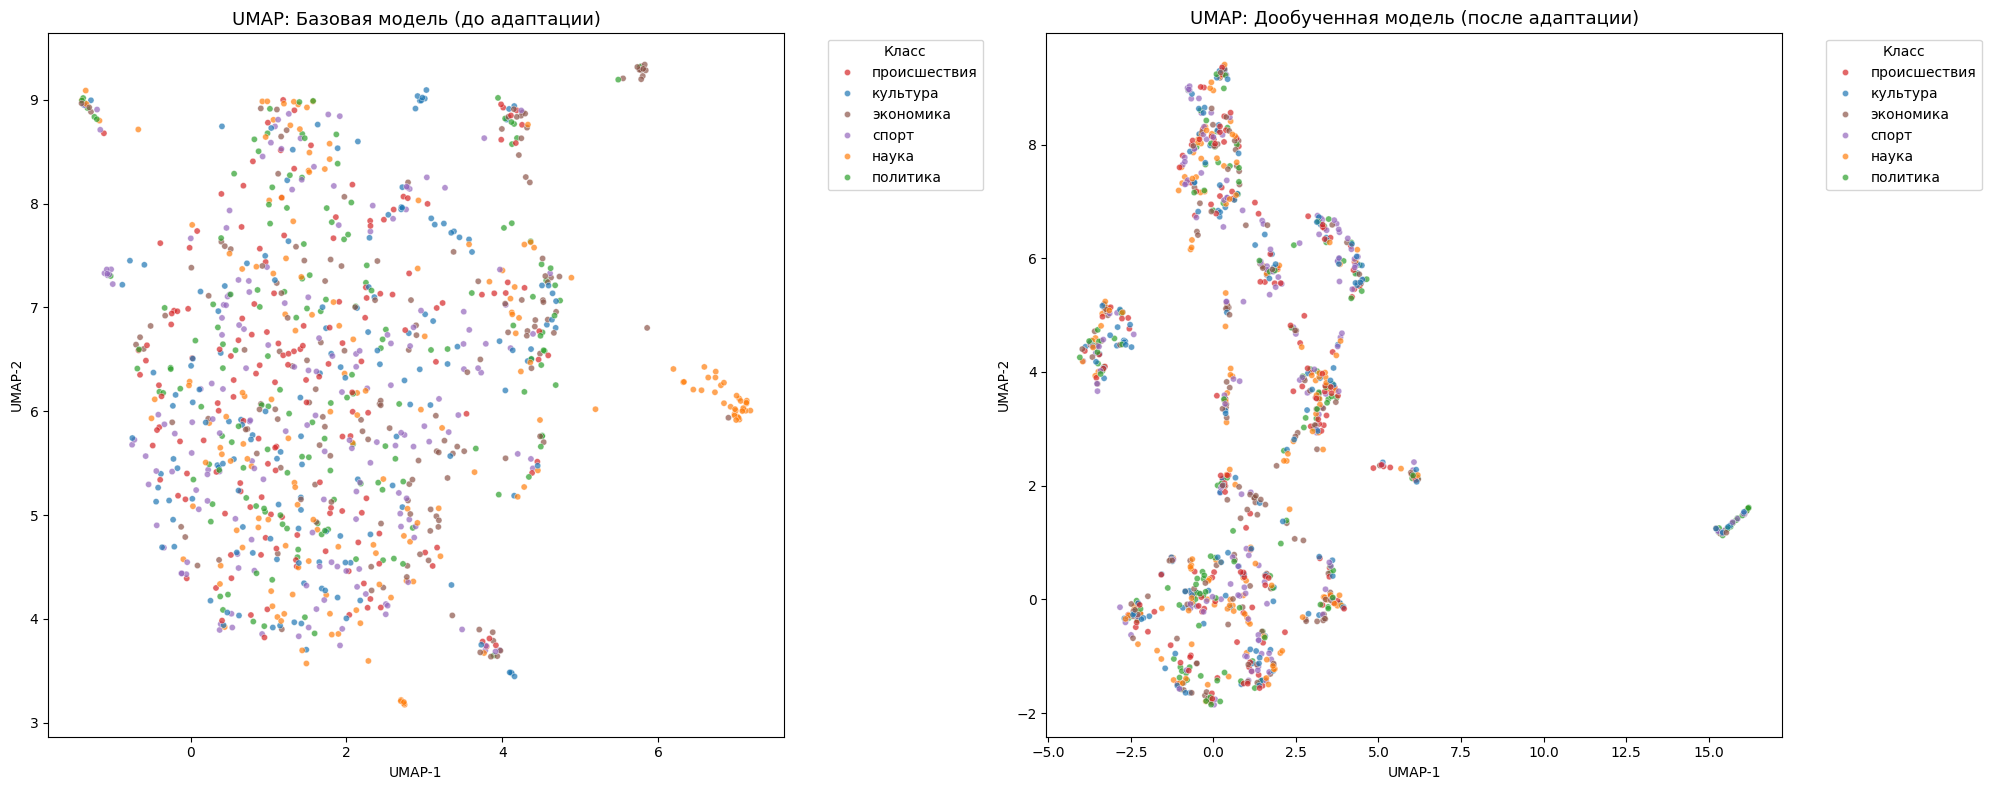

In [12]:
# Ваш код здесь: получение эмбеддингов дообученной моделью и визуализация
finetuned_embeddings = finetuned_model.encode(
    vis_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

finetuned_embeddings_2d = plot_embeddings(finetuned_embeddings, vis_labels, "UMAP: Дообученная модель")
# plot_embeddings(finetuned_embeddings, vis_labels, "UMAP: Дообученная модель") - Немного тоже подправил, в переменную finetuned_embeddings_2d сохраняю.

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)

base_2d = reducer.fit_transform(base_embeddings)
df_base = pd.DataFrame({"x": base_2d[:, 0], "y": base_2d[:, 1], "label": vis_labels})

reducer2 = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)

finetuned_2d = reducer2.fit_transform(finetuned_embeddings)
df_ft = pd.DataFrame({"x": finetuned_2d[:, 0], "y": finetuned_2d[:, 1], "label": vis_labels})

unique_labels = sorted(set(vis_labels))
palette = dict(zip(unique_labels, sns.color_palette("tab10", len(unique_labels))))

sns.scatterplot(data=df_base, x="x", y="y", hue="label", palette=palette, s=20, alpha=0.7, ax=axes[0])
axes[0].set_title("UMAP: Базовая модель (до адаптации)", fontsize=13)
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Класс")

sns.scatterplot(data=df_ft, x="x", y="y", hue="label", palette=palette, s=20, alpha=0.7, ax=axes[1])
axes[1].set_title("UMAP: Дообученная модель (после адаптации)", fontsize=13)
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Класс")

plt.tight_layout()
plt.savefig("umap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Сравнение графиков UMAP: стали ли кластеры более разделимыми?

До адаптации: все 1000 точек образуют одно плотное перемешанное "облако",
классы (спорт, политика, экономика и др.) практически не разделены —
базовая модель не понимает семантику русского текста.

После адаптации: пространство эмбеддингов кардинально изменило структуру —
появились чёткие обособленные кластеры, точки больше не образуют единое
облако. Однако внутри каждого кластера по-прежнему присутствуют точки
разных тематических классов. Таким образом, модель научилась группировать
тексты по каким-то внутренним признакам (скорее всего, лексическим паттернам,
характерным для парафраз), но не по тематическим категориям.

Вывод: кластеры формально стали более выраженными и разделёнными, однако
тематическая разделимость (спорт vs политика vs экономика) не улучшилась —
модель обучилась другому типу группировки, нежелательному для нашей задачи

### Выводы

Напишите краткий вывод по результатам эксперимента. Улучшились ли метрики? Как изменилась визуализация кластеров? Почему доменная адаптация на парафразах могла дать именно такой результат на задаче QA-поиска?

**Ваш ответ:**

В ходе эксперимента была выполнена доменная адаптация англоязычной модели
sentence-transformers/all-MiniLM-L6-v2 для работы с русскоязычными текстами
с использованием TripletLoss на датасете парафраз ru-HNP.

> Улучшились ли метрики?

Метрики семантического поиска (Recall@5 и Recall@10) после дообучения
не улучшились, а напротив — ухудшились примерно в 3-4 раза (Recall@5:
0.0272 -> 0.0061, Recall@10: 0.0350 -> 0.0105).

> Как изменилась визуализация кластеров?

Визуализация пространства эмбеддингов через UMAP показала противоречивую
картину: если до адаптации все точки образовывали одно бесструктурное
перемешанное облако, то после адаптации в пространстве эмбеддингов
появились чёткие обособленные кластеры. Однако тематическая разделимость
классов (спорт, политика, экономика и др.) внутри этих кластеров
не улучшилась — модель научилась группировать тексты не по смыслу,
а по иным признакам.

> Почему доменная адаптация на парафразах могла дать именно такой результат на задаче QA-поиска?

Такой результат объясняется фундаментальным несоответствием между задачей
обучения и задачей оценки. TripletLoss на парафразах обучает модель
сближать тексты, которые говорят одно и то же разными словами. Задача же
QA-поиска принципиально иная: нужно сопоставить вопрос с релевантным
документом, которые семантически близки, но лексически совершенно различны
и не являются парафразами друг друга. В результате дообучение на парафразах
не только не помогло решить задачу поиска, но и частично разрушило исходные
обобщённые представления модели (эффект катастрофического забывания).

Для достижения реального улучшения на задаче QA-поиска следовало бы
использовать данные формата вопрос-ответ (например, SberQuAD или ru-MIRACL)
и функцию потерь MultipleNegativesRankingLoss, специально разработанную
для задач retrieval.


